# datacenter optimization

## imports

In [ ]:
"""
Solves the optimal dispatch for the UPS in a data center to minize the variation in the data center's load 
with full knowledge of the future load values
"""

import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
from datacenter_network_class import Network, DataCenters

data_path = "../data/traces_raw"

## network

In [2]:
####################
##   Network
####################

V_BASE = 12.66 * 1e3    # 12.66 kV
S_BASE = 100 * 1e6      # 100 MVA

bus_data_file = 'Bus_Data_33bus.csv'  # TODO: Check against https://matpower.org/docs/ref/matpower6.0/case33bw.html
branch_data_file = 'Branch_Data_33bus.csv'
rx_scale = 1 / (V_BASE**2 / S_BASE)
pq_scale = 1 * 1e3 / S_BASE

pq_scale *= 0.3 # Scale down the load at other buses to reduce voltage drop
 
network = Network([bus_data_file, branch_data_file], rx_scale, pq_scale, slack_bus=1)
n_buses = network.n_buses

dt = 0.1 # Timestep
# T = int((60 * 60) / dt)  # 60 x 60 second intervals --> 60 minutes
# time = np.arange(T)
 
# Default Loads
rng = np.random.default_rng(seed=2)
Pd = network.Pd
Qd = network.Qd

print(f"{len(network.bus_ids)} buses loaded, {len(network.edges)} branches.")
print("Example: Bus 1 load:", Pd[network.idx_map[1]], Qd[network.idx_map[1]])

33 buses loaded, 32 branches.
Example: Bus 1 load: 0.0 0.0


## datacenter

In [ ]:
####################
##   Data Centers
####################

# Datacenter load specs
dc_backup_time = 60*1 # seconds
T_backup = int(dc_backup_time / dt)  # 60 * 1 # 300 x 1 second intervals --> 5 minutes

t_horizon = dc_backup_time # seconds
T_horizon = int(t_horizon / dt)

T_start = T_horizon + T_backup

# NOTE: MY code
# T = 36000 - (T_start+T_horizon+T_backup)
T = 22177 - (T_start+T_horizon+T_backup)
time = np.arange(T)

loadtime = np.arange(T_start+T+T_horizon)
backuploadtime = np.arange(T_start+T+T_horizon+T_backup)
pf = 0.995

dc1_bus = 6  # bus number
dc1_power_MW = 1.0 # MW rated DC
dc_pdu = [dc1_bus,]  #  Multiple PDUs at one bus indicate that they are within a single data center
dc_pdu_rating = [dc1_power_MW*1e6/S_BASE,]  # The rating of the PDUs used to scale the load profile

dc_stor = dc_pdu #  Multiple UPS storage at one bus indicate they are aggregated in one data center
dc_stor_power_rating = dc_pdu_rating# The rating of the PDUs used to scale the load profile
dc_stor_duration = [dc_backup_time,]  # The duration of the storage units in seconds


# UPS to PDU connectivity
#* Single UPS *#
ups_to_pdu_connectivity = [(0,)]

# Define data centers   
datacenter = DataCenters(network.idx_map,
                          dc_bus_loc=dc_pdu, 
                          dc_stor_loc=dc_stor, 
                          dc_power_rating=dc_pdu_rating, 
                          stor_power_rating = dc_stor_power_rating,
                          ups_poi_power_rating = dc_stor_power_rating,
                          stor_duration = dc_stor_duration, 
                          ups_pdu_connection = ups_to_pdu_connectivity, 
                          dc_backup_time = dc_backup_time, # Duration of the time until the backup generator can be brought online for each UPS
                          load_pf=pf)

dc_load_start_idx  = int(0 / dt) # 250s: Some start up, 400s: start of training, 500s: mid-step
# # Note: If the specified length is longer than the given traces, the start_idx = 0
# dc_Pinj_MW_t, dc_Qinj_MVAR_t = datacenter.generate_load_profile(T_start+T+T_horizon+T_backup, data_path, dt, dt_orig=0.1, start_idx=dc_load_start_idx)
dc_Pinj_MW_t, dc_Qinj_MVAR_t = datacenter.generate_load_profile(T_start+T+T_horizon+T_backup, data_path, dt, dt_orig=0.1, start_idx=dc_load_start_idx, max_shift=0, noise_frac=0.0)

['L2-70B-chat_4xH200_HF_qlora_tp_async_b16x2_seq2048_r64_ckpt1.csv']
data_arr.shape (1, 22168)
T > T_data: Appending zeros to the end of the array and setting start_idx = 0...
T > T_data: Appending zeros to the end of the array and setting start_idx = 0...
T > T_data: Appending zeros to the end of the array and setting start_idx = 0...
T > T_data: Appending zeros to the end of the array and setting start_idx = 0...
T > T_data: Appending zeros to the end of the array and setting start_idx = 0...
T > T_data: Appending zeros to the end of the array and setting start_idx = 0...
T > T_data: Appending zeros to the end of the array and setting start_idx = 0...
T > T_data: Appending zeros to the end of the array and setting start_idx = 0...
self.dc_Pinj_MW_t.shape (22177, 1)
Average Total Data Center Load: 0.007149240797381663
Max Possible Data Center Load: 0.01


In [4]:
T_start

1200

## storage model

In [ ]:
######################################
##   Storage Model
######################################
class Storage():
    def __init__(self, bus_idx, power_rating, duration, soc_min=0.8, soc_max=1.0, soc_nom=None, soc0=None, droop_coeff=1.0):
        if soc_min > soc_max:   raise ValueError("Min SoC greater than Max SoC")
        if soc0 is None:
            if soc_nom is None:
                soc_nom = (soc_min + soc_max) / 2
            soc0 = soc_nom
        elif soc_nom is None:
            soc_nom = soc0
        
        soc0 = soc_nom if soc_nom is None else soc0
        if soc_min > soc0:      raise ValueError("Initial SoC less than minimum SoC")
        
        self.soc_nom = soc0

        self.bus_idx = bus_idx

        self.power_rating = power_rating
        self.duration = duration
        self.energy_rating = power_rating * duration

        self.e_upper_lim = self.energy_rating * soc_max
        self.e_lower_lim = self.energy_rating * soc_min
        self.e = soc0 * self.energy_rating  # Initialize energy stored

        self.droop_coeff = droop_coeff

    # Historic Power Droop Controller
    def hist_power_droop(self, dc_Pinj_MW_t, T_horizon, dt):
        # Calculates a storage active power dispatch that aims to regulate the given power trace towards the average value of the past T_horizon steps.
        # Setting the droop coefficient to 1 results in the dispatch aiming to regulate the power trace fully to the average historic value. 
        load_length = len(dc_Pinj_MW_t)

        if load_length > T_horizon:
            Pinj_dc_hist_nom = np.mean(dc_Pinj_MW_t[-T_horizon:-1])
        else:
            Pinj_dc_hist_nom = np.mean(dc_Pinj_MW_t[0:load_length-1])
        Pinj_dc = dc_Pinj_MW_t[-1]
        
        #soc_droop = np.exp(-(10**2)*(e / e_upper_lim - soc_nom)**2)  # Penalize deviating from the nominal SoC
        soc_droop = 1

        dc_stor_dispatch = np.max([(self.e - self.e_upper_lim) / dt, np.min([(self.e - self.e_lower_lim) / dt, self.droop_coeff * soc_droop * (Pinj_dc - Pinj_dc_hist_nom)])])
        return dc_stor_dispatch
    
    def step(self, p, dt):
        self.e = self.e - p * dt

# Construct the storage unit associated with the data center
max_dc_load = np.max(dc_Pinj_MW_t)
stor = Storage(bus_idx=dc1_bus, power_rating=max_dc_load, duration=T_backup, soc_min=0.93, soc_max=0.97, soc0=0.95, droop_coeff=0.6)

## loads

Text(0.5, 1.0, 'PDU Level Data Center Load')

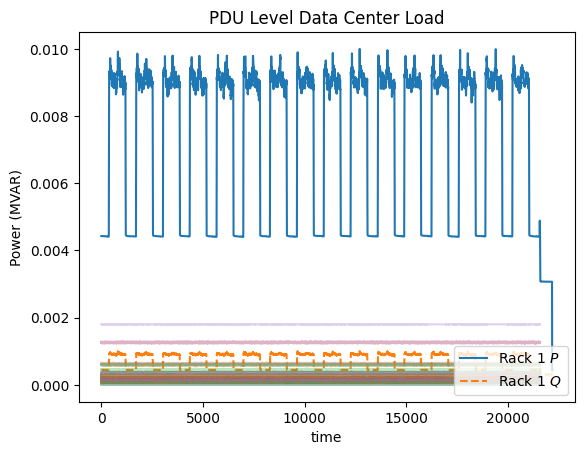

In [6]:
####################
##   Loads
####################

# Set up bus loads
Pinj_MW_t = np.abs(np.ones((T_start + T + T_horizon, n_buses)) * Pd + rng.normal(0.0, 1e3/S_BASE, (T_start + T + T_horizon, n_buses)))
Qinj_MVAR_t = np.ones((T_start + T + T_horizon, n_buses)) * Qd + rng.normal(0.0, 1e2/S_BASE, (T_start + T + T_horizon, n_buses))

# Add static reactive power compensation at DC bus, Positive is reactive power injection
Q_static = np.zeros(n_buses)
# Q_static[network.idx_map[dc_pdu[0]]] = 0.005 # Manually added reactive compensation at DC bus
# Q_static[network.idx_map[18]] = 0.005 # Manually added reactive compensation at end of branch bus 18
Qinj_MVAR_t -= Q_static

plt.figure()
plt.plot(backuploadtime, dc_Pinj_MW_t, linestyle='-')
plt.plot(backuploadtime, dc_Qinj_MVAR_t, linestyle='--')
plt.plot(loadtime, Pinj_MW_t, alpha=0.3)
plt.plot(loadtime, Qinj_MVAR_t, linestyle='-', alpha=0.3)
plt.xlabel("time"), plt.ylabel("Power (MVAR)")
plt.legend(["Rack %s $P$" % (i+1) for i in range(len(dc_pdu))] + ["Rack %s $Q$" % (i+1) for i in range(len(dc_pdu))], loc="lower right")
plt.title("PDU Level Data Center Load")

# fname=r"results/DataCenterLoads.pdf"
# plt.savefig(fname, dpi=300, format=None, metadata=None,
#         bbox_inches=None, pad_inches=0.0,
#         facecolor='auto', edgecolor='auto',
#         backend=None
#        )

# plt.show()

## simulations

### w/ regulation

In [7]:
####################
## Simulations
####################

# === Run simulation to solve for voltage at each step time WITH regulation === #
v0 = 1.0  # squared voltage at slack bus
Vm = v0 * np.ones(n_buses)

# Run the simulation

import time
# === Run simulation with a historic power droop controller

# Run the simulation
results_reg = {"V": [],
                 "e": [],
                 "uP": [],
                 "uQ": [],
                 "Pinj": [],
                 "Qinj": [],
                 "Pinj_dc": [],
                 "Qinj_dc": [],
                 "e_lower_lim": [],
                 }

T_horizon = 1000

import time
start = time.time()
for t in range(T_start, T_start+T):
    if (t-T_start) % max(T // 100, 1) == 0:
        print(f"Timestep {t-T_start} of {T}, runtime: {time.time() - start}")


    # Initialize voltage estimates for droop
    V_est = np.ones(n_buses)
    V_est[1:] = Vm[1:] 

    ##################################################################
    # STORAGE DISPATCH CODE
    ##################################################################

    # Solve for and apply control
    if t > T_horizon:
        dc_i_Pinj_MW_t = dc_Pinj_MW_t[t-T_horizon:t, 0]
    else:
        dc_i_Pinj_MW_t_delay = dc_Pinj_MW_t[0:t+1, 0]

    uP_t = stor.hist_power_droop(dc_i_Pinj_MW_t, T_horizon, dt)
    if uP_t == np.inf:
        print("huh")
    uQ_t = 0

    # Save previous SoC level and step storage SoC based on dispatch
    results_reg["e"].append(np.array([stor.e]).copy())  # Save storage energy before applying power dispatch
    stor.step(uP_t, dt)

    results_reg["uP"].append(np.array([uP_t]).copy())
    results_reg["uQ"].append(np.array([uQ_t]).copy())
    ##################################################################
    ##################################################################

    Pinj_pu = np.copy(Pinj_MW_t[t])
    Qinj_pu = np.copy(Qinj_MVAR_t[t])
    for dc_i, dc_bus_idx in enumerate(datacenter.bus_idxs):  # Iterates over all data center PDUs
        Pinj_dc = dc_Pinj_MW_t[t][dc_i]  # Note these are PDU level loads
        Qinj_dc = dc_Qinj_MVAR_t[t][dc_i]    
        Pinj_pu[dc_bus_idx] = Pinj_pu[dc_bus_idx] + Pinj_dc
        Qinj_pu[dc_bus_idx] = Qinj_pu[dc_bus_idx] + Qinj_dc 

    # Add in storage dispatch 
    Pinj_pu[stor.bus_idx] = Pinj_pu[stor.bus_idx] - uP_t
    Qinj_pu[stor.bus_idx] = Qinj_pu[stor.bus_idx] - uQ_t 

    Pinj_previous1 = np.copy(Pinj_pu)
    Qinj_previous1 = np.copy(Qinj_pu)
    Vm = network.calculate_voltage_sqrt(v0, Pinj_full=Pinj_previous1, Qinj_full=Qinj_previous1)
    results_reg["V"].append(Vm.copy())
    
    # Save bus power injection values
    results_reg["Pinj"].append(Pinj_pu.copy())
    results_reg["Qinj"].append(Qinj_pu.copy())
    results_reg["Pinj_dc"].append(np.sum(dc_Pinj_MW_t[t]) - np.sum(uP_t))  # TODO: Determine how to best handle this. Should it be at a pdu level? dc level? bus level? Right now this is summing all which won't work with multiple DCs...
    results_reg["Qinj_dc"].append(np.sum(dc_Qinj_MVAR_t[t]) - np.sum(uQ_t))
end = time.time()
print(f"Simulation total runtime: {end - start}")


Timestep 0 of 19777, runtime: 0.00019931793212890625
Timestep 197 of 19777, runtime: 0.04424166679382324
Timestep 394 of 19777, runtime: 0.07441520690917969
Timestep 591 of 19777, runtime: 0.10654473304748535
Timestep 788 of 19777, runtime: 0.14291644096374512
Timestep 985 of 19777, runtime: 0.1780385971069336
Timestep 1182 of 19777, runtime: 0.21137690544128418
Timestep 1379 of 19777, runtime: 0.24474453926086426
Timestep 1576 of 19777, runtime: 0.2754528522491455
Timestep 1773 of 19777, runtime: 0.30013394355773926
Timestep 1970 of 19777, runtime: 0.3291902542114258
Timestep 2167 of 19777, runtime: 0.357982873916626
Timestep 2364 of 19777, runtime: 0.3852250576019287
Timestep 2561 of 19777, runtime: 0.4141874313354492
Timestep 2758 of 19777, runtime: 0.44190239906311035
Timestep 2955 of 19777, runtime: 0.4733729362487793
Timestep 3152 of 19777, runtime: 0.5024399757385254
Timestep 3349 of 19777, runtime: 0.5313067436218262
Timestep 3546 of 19777, runtime: 0.5589263439178467
Timestep 

### w/o regulation

In [8]:
# === Run simulation to solve for voltage at each step time WITHOUT regulation === #

# Run the simulation
results_noreg = {"V": [],
                 "e": [],
                 "Pinj": [],
                 "Qinj": [],
                 "Pinj_dc": [],
                 "Qinj_dc": []
                 }
e0_start = 0.9 * datacenter.stor.energy_rating
for t in range(T_start, T_start+T):
    # Per-unit injections
    Pinj_pu_t = Pinj_MW_t[t]
    Qinj_pu_t = Qinj_MVAR_t[t]


    # Initialize voltage estimates for droop
    V_est = np.ones(n_buses)
    V_est[1:] = Vm[1:]

    # No control case
    Pinj_pu = np.copy(Pinj_pu_t)
    Qinj_pu = np.copy(Qinj_pu_t)
    for dc_i, dc_bus_idx in enumerate(datacenter.bus_idxs):
        Pinj_dc = dc_Pinj_MW_t[t][dc_i]
        Qinj_dc = dc_Qinj_MVAR_t[t][dc_i]        

        Pinj_pu[dc_bus_idx] = Pinj_pu[dc_bus_idx] + Pinj_dc
        Qinj_pu[dc_bus_idx] = Qinj_pu[dc_bus_idx] + Qinj_dc 

    Pinj_previous1 = np.copy(Pinj_pu)
    Qinj_previous1 = np.copy(Qinj_pu)
    Vm_orig = network.calculate_voltage_sqrt(v0, Pinj_full=Pinj_previous1, Qinj_full=Qinj_previous1)
    results_noreg["V"].append(Vm_orig.copy())
    results_noreg["e"].append(e0_start.copy())
    results_noreg["Pinj"].append(Pinj_pu.copy())
    results_noreg["Qinj"].append(Qinj_pu.copy())
    results_noreg["Pinj_dc"].append(np.sum(dc_Pinj_MW_t[t].copy()))
    results_noreg["Qinj_dc"].append(np.sum(dc_Qinj_MVAR_t[t].copy()))


### summary

In [9]:
# === Output ===

print("Voltages deviations without regulation (pu):", np.min(results_noreg["V"], axis=0), np.max(results_noreg["V"], axis=0))
print("Voltages deviations with regulation (pu):", np.min(results_reg["V"], axis=0), np.max(results_reg["V"], axis=0))

# Save the results data and the input load
results = {"Results No Regulation": results_noreg,
           "Results with Regulation": results_reg,
           "Base Data Center Load": {"P": np.sum(dc_Pinj_MW_t, axis=1), "Q": np.sum(dc_Qinj_MVAR_t, axis=1)},
           }

# import pickle as pkl
# with open('results_1hr.pickle', 'wb') as handle:
#     pkl.dump(results, handle, protocol=pkl.HIGHEST_PROTOCOL)

Voltages deviations without regulation (pu): [1.         0.99709822 0.9827017  0.97371767 0.96459388 0.94335239
 0.94141188 0.93867387 0.93515453 0.93191233 0.93143235 0.93059247
 0.92717935 0.92592868 0.92515412 0.92440701 0.92330502 0.92298233
 0.99678142 0.99457436 0.99413707 0.99373494 0.98063004 0.97671429
 0.97476149 0.94228145 0.94085945 0.93454574 0.9299935  0.9280235
 0.92572769 0.92522172 0.92506431] [1.         0.99780281 0.98712405 0.98091285 0.97467693 0.95978538
 0.95787867 0.95529436 0.95194216 0.94885496 0.94839774 0.94759689
 0.94437153 0.94317652 0.9424512  0.94174439 0.94070093 0.94038995
 0.99749764 0.99548984 0.9950957  0.99473565 0.98505245 0.98121036
 0.97930841 0.95873312 0.95733798 0.95110175 0.94662051 0.94469069
 0.94244712 0.94195397 0.94181075]
Voltages deviations with regulation (pu): [1.         0.99726473 0.98374335 0.97542473 0.96699431 0.94727017
 0.94544233 0.94267324 0.93910903 0.93580257 0.93531112 0.93445549
 0.93099123 0.92971662 0.92891077 0.9281

## plot

### system-side voltage

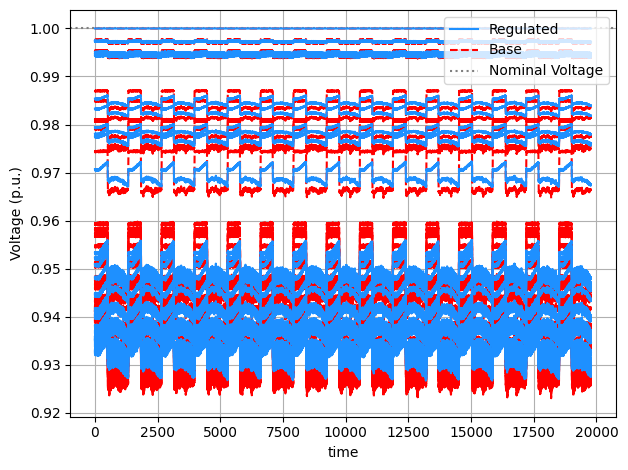

In [10]:
# Voltage magnitude only plot
fig, ax = plt.subplots(1, 1, figsize=[6.4, 4.8], sharex=True)
axs = [ax]
lines_reg = plt.plot(np.array(results_reg["V"]), color='dodgerblue', zorder=4)
lines_noreg = plt.plot(np.array(results_noreg["V"]), color='red', linestyle="--")
lines_nom = plt.axhline(1.0, color='gray', linestyle=':')
plt.ylabel('Voltage (p.u.)')
plt.xlabel('time')
plt.legend([lines_reg[0], lines_noreg[0], lines_nom], ["Regulated", "Base", 'Nominal Voltage'], loc="upper right")
plt.grid(True)
plt.tight_layout()

# fname=r"results/VoltagesWith.pdf"
# plt.savefig(fname, dpi=300, format=None, metadata=None,
#         bbox_inches=None, pad_inches=0.0,
#         facecolor='auto', edgecolor='auto',
#         backend=None
#        )

### datacenter bus

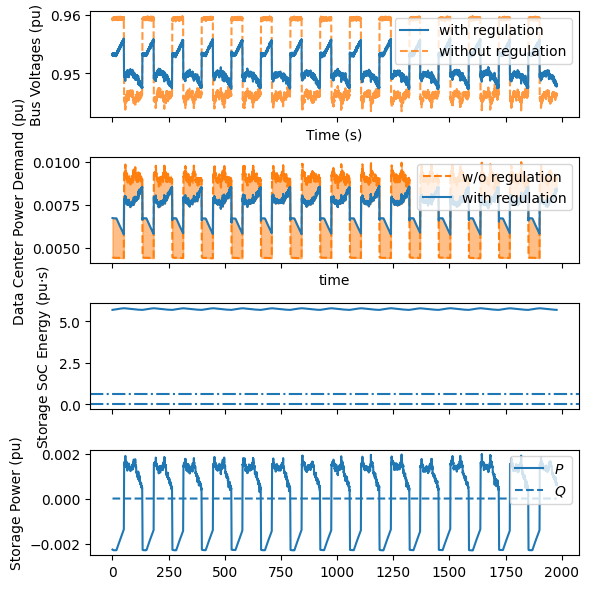

In [11]:
### Plot values together
# Plot voltage at data center bus
fig, axs = plt.subplots(4, 1, figsize=(6, 6), sharex=True)
ts = np.arange(0, T*dt, dt)
lnwreg = axs[0].plot(ts, np.array(results_reg["V"])[:, datacenter.bus_idxs[0]], label="with regulation", color='C0', zorder=4, linestyle='-')
axs[0].set_prop_cycle(None)
lnworeg =axs[0].plot(ts, np.array(results_noreg["V"])[:, datacenter.bus_idxs[0]], label="without regulation", linestyle='--', color='C1', alpha=0.8)
handles = [lnwreg[0], lnworeg[0]]
axs[0].legend(handles, ["with regulation", "without regulation"], loc="upper right")
axs[0].set_ylabel("Bus Voltages (pu)")
axs[0].set_xlabel("Time (s)")
# Plot total data center load at that bus  #TODO: update this to select a specified data center bus
axs[1].plot(ts, np.array(results_noreg["Pinj_dc"])[:len(ts)], linestyle='--', label=r"w/o regulation", color='C1')
axs[1].plot(ts, np.array(results_reg["Pinj_dc"])[:len(ts)], linestyle='-', label=r"with regulation", color='C0')  # Plot regulated load and fill between
axs[1].fill_between(ts, np.array(results_reg["Pinj_dc"])[:len(ts)], np.array(results_noreg["Pinj_dc"])[:len(ts)], alpha=0.5, color='C1')
axs[1].set_xlabel("time"), axs[1].set_ylabel("Data Center Power Demand (pu)")
axs[1].legend(loc="upper right")
# Plot storage SoC
axs[2].plot(ts, np.array(results_reg["e"]))  # Scale to pu*s by multiplpying by dt / s (# of seconds in each time step)
axs[2].set_prop_cycle(None)
# axs[2].plot(ts, np.array(results_reg["e_lower_lim"]), linestyle='--')
[axs[2].axhline(elim_val, linestyle='-.', color='C%s' % i) for i, elim_val in enumerate(datacenter.stor.e_upper_lim)]
axs[2].set_prop_cycle(None)
[axs[2].axhline(elim_val, linestyle='-.', color='C%s' % i) for i, elim_val in enumerate(datacenter.stor.e_lower_lim)]
axs[2].set_ylabel(r"Storage SoC Energy (pu$\cdot$s)")
# Plot storage dispatch
lineP = axs[3].plot(ts, np.array(results_reg["uP"]), linestyle='-')
axs[3].set_prop_cycle(None)
lineQ = axs[3].plot(ts, np.array(results_reg["uQ"]), linestyle='--')
axs[3].set_ylabel(r"Storage Power (pu)")
axs[3].legend([lineP[0], lineQ[0]], [r"$P$", r"$Q$"], loc="upper right")

plt.tight_layout()

### net load

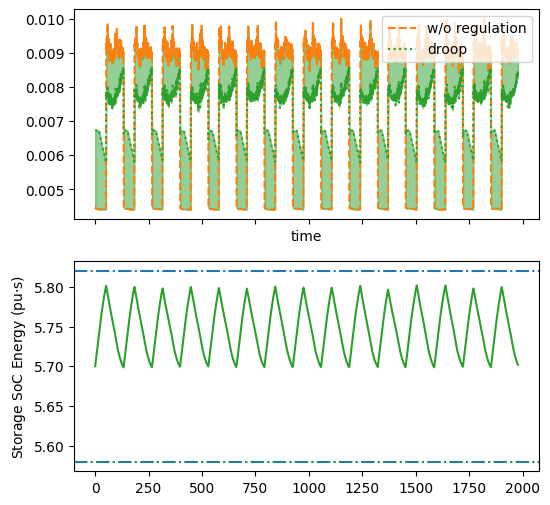

In [12]:
# === Plot storage energy and resulting net data center load
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
ts = np.arange(0, T*dt, dt)
# Plot total data center load at that bus 
axs[0].plot(ts, np.array(results_noreg["Pinj_dc"])[:len(ts)], linestyle='--', label=r"w/o regulation", color='C1')
axs[0].plot(ts, np.array(results_reg["Pinj_dc"])[:len(ts)], linestyle=':', label=r"droop", color='C2') 
axs[0].fill_between(ts, np.array(results_reg["Pinj_dc"])[:len(ts)], np.array(results_noreg["Pinj_dc"])[:len(ts)], alpha=0.5, color='C2')
axs[0].set_xlabel("time"), axs[1].set_ylabel("Data Center Power Demand (pu)")
axs[0].legend(loc="upper right")
# Plot storage SoC
axs[1].plot(ts, np.array(results_reg["e"]), color="C2")
axs[1].set_prop_cycle(None)
[axs[1].axhline(elim_val, linestyle='-.', color="C0") for i, elim_val in enumerate([stor.e_upper_lim])]
axs[1].set_prop_cycle(None)
[axs[1].axhline(elim_val, linestyle='-.', color="C0") for i, elim_val in enumerate([stor.e_lower_lim])]
[axs[1].axhline(elim_val, linestyle=':', color="C2", alpha=0.5) for i, elim_val in enumerate([stor.e_lower_lim])]  # Linear control lower limit
axs[1].set_ylabel(r"Storage SoC Energy (pu$\cdot$s)")

plt.show()

## summarize

### plot

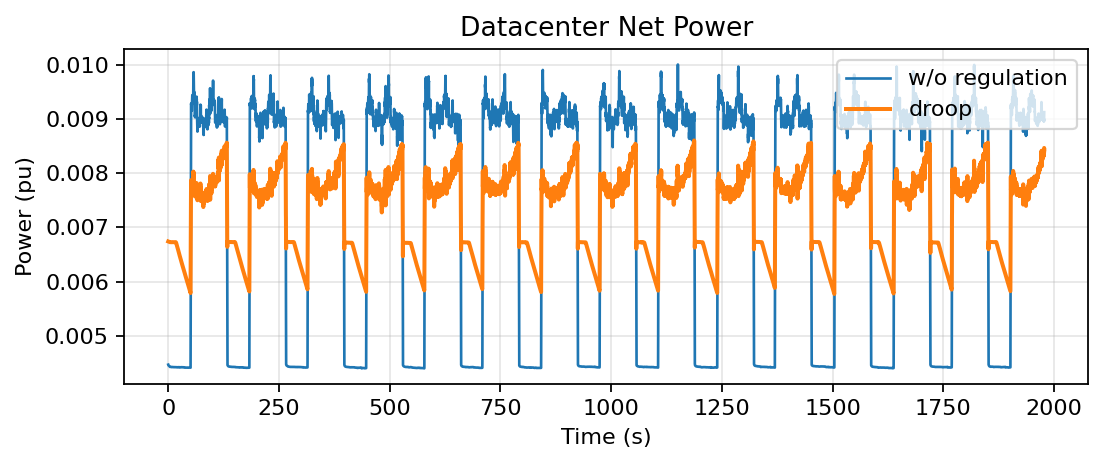

In [13]:
# time axis
ts = np.arange(0, T * dt, dt)

# data
P_base = np.array(results_noreg["Pinj_dc"][:len(ts)])   # original datacenter load
P_net  = np.array(results_reg["Pinj_dc"][:len(ts)])     # net load after droop

# plot
plt.figure(figsize=(7, 3), dpi=160)

plt.plot(ts, P_base, lw=1.2, label="w/o regulation")
plt.plot(ts, P_net,  lw=1.8, label="droop")

plt.xlabel("Time (s)")
plt.ylabel("Power (pu)")
plt.title("Datacenter Net Power")
plt.grid(alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [14]:
P_base[0], P_net[0]

(np.float64(0.004470337967898421), np.float64(0.006740217973649668))

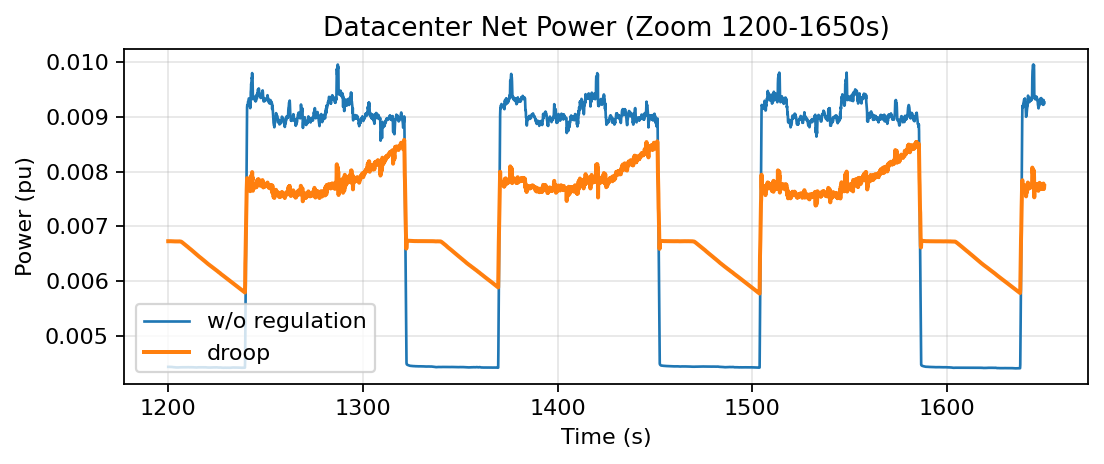

In [15]:
t0, t1 = 1200, 1650   # seconds

mask = (ts >= t0) & (ts <= t1)

plt.figure(figsize=(7,3), dpi=160)

plt.plot(ts[mask], P_base[mask], lw=1.2, label="w/o regulation")
plt.plot(ts[mask], P_net[mask],  lw=1.8, label="droop")

plt.xlabel("Time (s)")
plt.ylabel("Power (pu)")
plt.title(f"Datacenter Net Power (Zoom {t0}-{t1}s)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### save

In [16]:
raise ValueError

ValueError: 

In [17]:
save_path = f"../results/dc_simulation_results_cut.pkl"

results = {
    "t": ts,
    "regulated": results_reg,
    "unregulated": results_noreg
}

with open(save_path, "wb") as f:
    pickle.dump(results, f)

print("Saved to:", save_path)

Saved to: ../results/dc_simulation_results_cut.pkl
